<a href="https://colab.research.google.com/github/saeedzainab274-bit/Brain-Tumor-Deep-Learning-project/blob/main/BrainTumor_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os

# Create the directories if they don't exist
os.makedirs('/content/yes', exist_ok=True)
os.makedirs('/content/no', exist_ok=True)

print("Directories '/content/yes' and '/content/no' created successfully.")

Directories '/content/yes' and '/content/no' created successfully.


In [4]:
import os

yes_path = "/content/yes"
no_path = "/content/no"

print("Tumor Images:", len(os.listdir(yes_path)))
print("No Tumor Images:", len(os.listdir(no_path)))

total = len(os.listdir(yes_path)) + len(os.listdir(no_path))
print("Total Images:", total)

Tumor Images: 0
No Tumor Images: 0
Total Images: 0


In [5]:
from PIL import Image
import os

def check_images(folder):
    bad_images = []

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            bad_images.append(img_name)

    return bad_images

bad_yes = check_images("/content/yes")
bad_no = check_images("/content/no")

print("Corrupted Tumor Images:", len(bad_yes))
print("Corrupted No Tumor Images:", len(bad_no))

Corrupted Tumor Images: 0
Corrupted No Tumor Images: 0


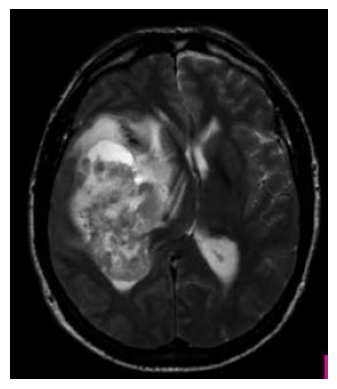

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import os

tumor_image = os.listdir("/content/yes")[0]
img = Image.open(f"/content/yes/{tumor_image}")

plt.imshow(img)
plt.axis("off")
plt.show()

In [10]:
import zipfile
import os

# Path to the zip file
zip_file_path = '/content/archive.zip'

# Directory where the contents will be extracted
extract_path = '/content/'

# Create the extract path if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"'{zip_file_path}' unzipped to '{extract_path}' successfully.")

# After unzipping, let's verify the contents of the 'yes' and 'no' folders again.
# Assuming the zip extracts directly into /content/yes and /content/no or similar structure.

# Re-check the counts
yes_path = '/content/yes'
no_path = '/content/no'

# Adjust paths if the extracted structure is different (e.g., /content/archive/yes)
# You might need to inspect the zip content or adjust these paths based on how the data is structured inside the zip.
# For example, if it extracts into a folder called 'data_set', you'd use '/content/data_set/yes'

# For now, let's assume direct extraction into /content/yes and /content/no or similar.
# If the actual structure is nested, the following lines might still show 0.
# The user will need to adjust 'yes_path' and 'no_path' if the extracted folder structure is different.

print("\nVerifying image counts after unzipping:")
print("Tumor Images:", len(os.listdir(yes_path)) if os.path.exists(yes_path) else "Path not found")
print("No Tumor Images:", len(os.listdir(no_path)) if os.path.exists(no_path) else "Path not found")

try:
    total = len(os.listdir(yes_path)) + len(os.listdir(no_path))
    print("Total Images:", total)
except TypeError: # Handle case where path not found returns a string instead of int
    print("Total Images: Cannot calculate, one or both paths not found.")


'/content/archive.zip' unzipped to '/content/' successfully.

Verifying image counts after unzipping:
Tumor Images: 155
No Tumor Images: 98
Total Images: 253


**Preprocessing**

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [12]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

In [13]:
train_data = datagen.flow_from_directory(
    "/content",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 432 images belonging to 5 classes.


In [14]:
val_data = datagen.flow_from_directory(
    "/content",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 74 images belonging to 5 classes.


**Train**/**split**

In [15]:
print(train_data.class_indices)

{'.config': 0, 'brain_tumor_dataset': 1, 'no': 2, 'sample_data': 3, 'yes': 4}


In [16]:
{'no': 0, 'yes': 1}

{'no': 0, 'yes': 1}

**visualised processed image**

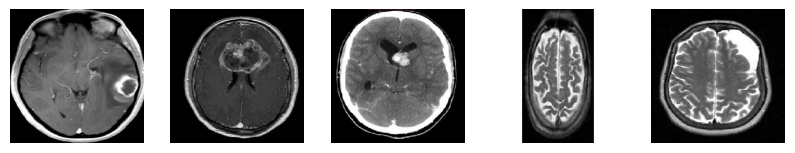

In [17]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()